In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "hyperspectral_oil_spill"
file_path = DATA_DIR / "GM01.mat"

try:
    mat_data = sio.loadmat(file_path)
except Exception as e:
    print(f"Error loading file. If it's a v7.3 mat file, you may need to use 'h5py' instead of 'scipy.io'. Error: {e}")
    exit()

# Print the keys to see how the author named the variables
print("Keys inside GM01.mat:")
for key in mat_data.keys():
    if not key.startswith('__'):  # Ignore Python/MATLAB metadata
        data_type = type(mat_data[key])
        shape = mat_data[key].shape if isinstance(mat_data[key], np.ndarray) else "N/A"
        print(f" - '{key}': Type {data_type}, Shape {shape}")

Keys inside GM01.mat:
 - 'img': Type <class 'numpy.ndarray'>, Shape (1243, 684, 224)
 - 'map': Type <class 'numpy.ndarray'>, Shape (1243, 684)


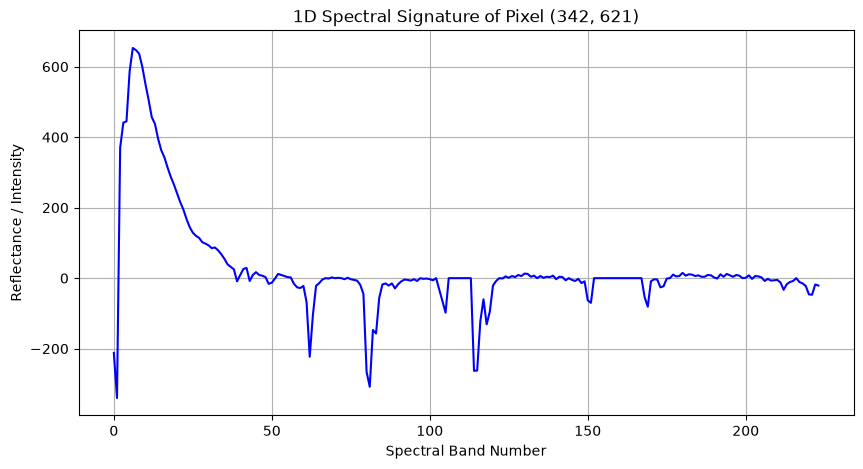

In [4]:
hsi_cube = mat_data["img"]  # Shape: (1243, 684, 224)

random_y = hsi_cube.shape[0] // 2
random_x = hsi_cube.shape[1] // 2
spectral_signature = hsi_cube[random_y, random_x, :]

plt.figure(figsize=(10, 5))
plt.plot(spectral_signature, color="blue", linewidth=1.5)
plt.title(f"1D Spectral Signature of Pixel ({random_x}, {random_y})")
plt.xlabel("Spectral Band Number")
plt.ylabel("Reflectance / Intensity")
plt.grid(True)
plt.show()

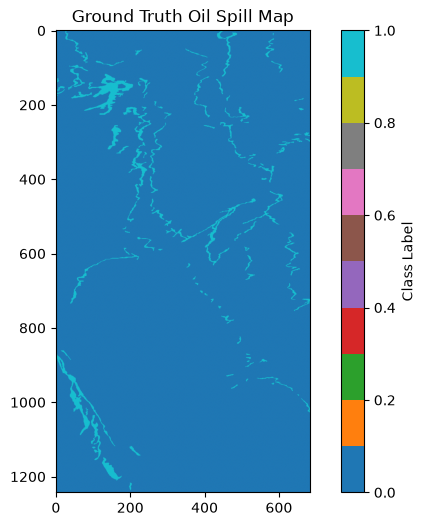

In [5]:
gt_map = mat_data["map"]  # Shape: (1243, 684)

plt.figure(figsize=(8, 6))
plt.imshow(gt_map, cmap="tab10")
plt.colorbar(label="Class Label")
plt.title("Ground Truth Oil Spill Map")
plt.show()

--- Class Distribution ---
Class 0: 820,876 pixels (96.55%)
Class 1: 29,336 pixels (3.45%)


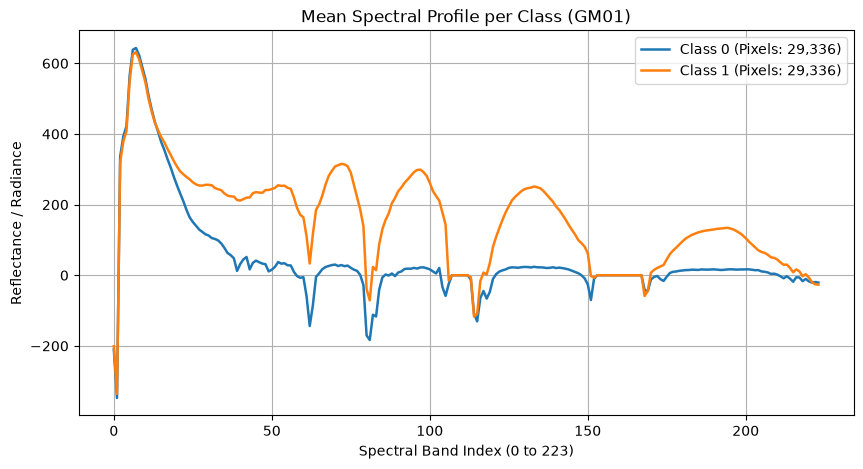

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img = mat_data["img"]   # (1243, 684, 224)
gt_map = mat_data["map"] # (1243, 684)

unique_labels, counts = np.unique(gt_map, return_counts=True)
total_pixels = gt_map.size

print("--- Class Distribution ---")
for label, count in zip(unique_labels, counts):
    pct = (count / total_pixels) * 100
    print(f"Class {label}: {count:,} pixels ({pct:.2f}%)")

# Plot Mean Spectral Signature for each class
plt.figure(figsize=(10, 5))
for label in unique_labels:
    mask = (gt_map == label)
    # Average across all spatial pixels belonging to this class
    mean_spectrum = img[mask].mean(axis=0)
    plt.plot(mean_spectrum, label=f"Class {label} (Pixels: {count:,})", linewidth=1.8)

plt.title("Mean Spectral Profile per Class (GM01)")
plt.xlabel("Spectral Band Index (0 to 223)")
plt.ylabel("Reflectance / Radiance")
plt.legend()
plt.grid(True)
plt.show()

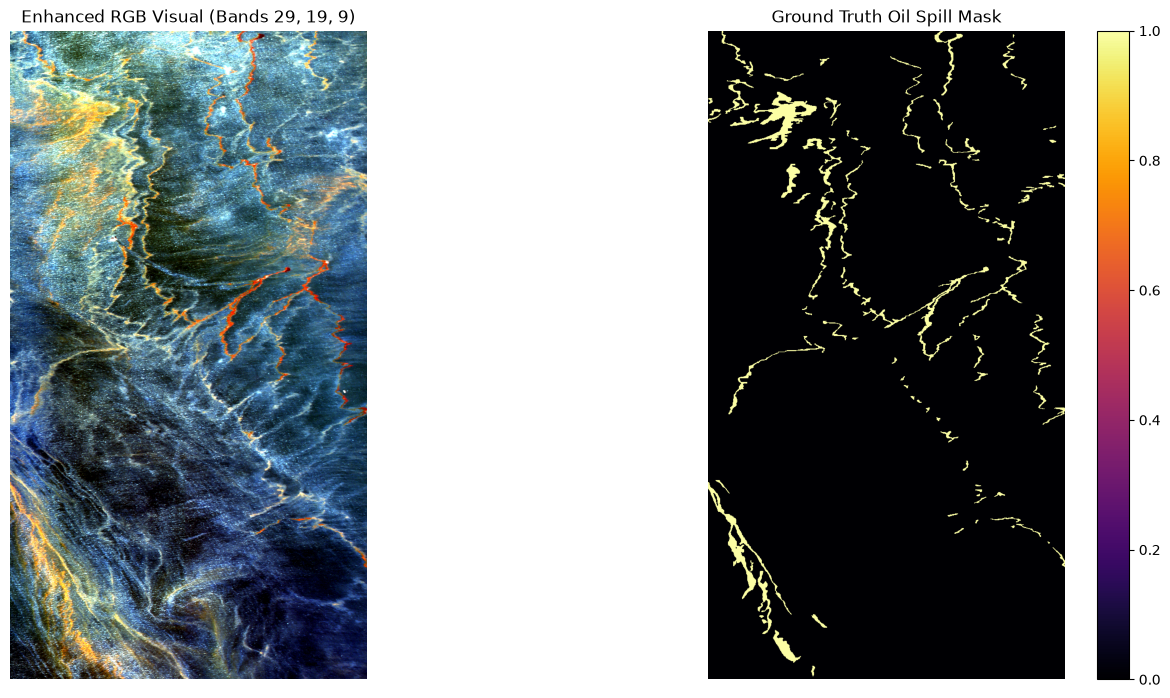

In [8]:
import numpy as np
import matplotlib.pyplot as plt

img = mat_data["img"]   # (1243, 684, 224)
gt_map = mat_data["map"] # (1243, 684)

# Choose Red, Green, Blue bands (approx ~650nm, ~550nm, ~480nm in AVIRIS)
rgb_bands = [29, 19, 9]
rgb_raw = img[:, :, rgb_bands].astype(np.float32)

# Mask out negative/bad fill values
rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)

# Percentile contrast stretch per channel (2nd to 98th percentile)
rgb_enhanced = np.zeros_like(rgb_clean)
for c in range(3):
    channel = rgb_clean[:, :, c]
    p_low, p_high = np.percentile(channel[channel > 0], (2, 98))
    channel_clipped = np.clip(channel, p_low, p_high)
    rgb_enhanced[:, :, c] = (channel_clipped - p_low) / (p_high - p_low + 1e-8)

# Plot side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(rgb_enhanced)
axs[0].set_title("Enhanced RGB Visual (Bands 29, 19, 9)")
axs[0].axis("off")

im = axs[1].imshow(gt_map, cmap="inferno")
axs[1].set_title("Ground Truth Oil Spill Mask")
axs[1].axis("off")
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()